# Project 2: Deep Learning-Based Question Answering System
## Course: Applied Natural Language Processing
### Name: Md Anwar Hossain
### Date: 06 April 2026

This project was completed as part of my Aplied Natural Language Processing course at Victoria University. **The Project instructions are given below:**

**Introduction:** Question  Answering  (QA)  systems  are  mainly  designed  to  fill  human  information  needs. 
Humans ask questions in many situations: when talking to a virtual assistant, when interacting with a search engine, when querying a database. Most question answering systems focus on a 
particular subset of these information needs: factoid questions, questions that can be answered with simple facts expressed in short texts, like the following:
(1) Who is the founder of Apple?
(2) What is the average age of the onset of autism?

Information-retrieval based QA, sometimes called open domain question QA, relies on the vast amount of text on the web or in collections of scientific papers like PubMed. Given a user question, information retrieval is used to find relevant passages. Then neural reading
comprehension algorithms read these retrieved passages and draw an answer directly from
spans of text. This project is meant to check your understanding about building a QA system 
for the given corpus.

**Dataset Description:**

The Stanford Question Answering Dataset (SQuAD) is a prime example of large-scale labeled datasets  for  reading  comprehension.  Rajpurkar  et  al.  developed  SQuAD  2.0 
https://rajpurkar.github.io/SQuAD-explorer/, combines 100,000 answerable questions with 50,000 unanswerable questions about the same paragraph from a set of Wikipedia articles. The unanswerable questions were written adversarially by crowd workers to look similar  to 
answerable ones.

**Examples of context, question and answer on SQuAD**

Context — Apollo ran from 1961 to 1972, and was supported by the two-man Gemini program which ran concurrently with it from 1962 to 1966. Gemini missions developed some of the 
space travel techniques that were necessary for the success of the Apollo missions. Apollo used Saturn family rockets as launch vehicles. Apollo/Saturn vehicles were also used for an Apollo 
Applications Program, which consisted of Skylab, a space station that supported three manned missions in 1973–74, and the Apollo–Soyuz Test Project, a joint Earth orbit mission with the 
Soviet Union in 1975.

Question — What space station supported three manned missions in 1973–1974? 
Answer — Skylab 

**Tasks to do:**

Write a code in Jupyter notebook to perform the following tasks. Develop a QA model with 
the key components described below.

1. Input Layer: Import the dataset into the model.

2. Embedding Layer: The training dataset consists of context and corresponding questions. They can be broken into individual words. The Glove vectors can be used 
to convert the words into word embeddings using pre-trained model. The word embeddings are better in capturing the context around the words. You can use 100 or 
300-dimension word embeddings depends on your choice.

3. Encoder Layer: The next layer in the model is encoder layer. Each word in the context needs  to  aware  of  the  previous  and  next  words  in  the  sequence.  Bidirectional 
LSTM/GRU can be used to train the model.

4. Attention Layer: It is the key component in AQ system, as the model needs to figure out the answer from the hidden vector of a context and question.

5. Output Layer: Softmax output layer is the final layer of the model that helps to locate the start and end index of the answer span.                                        


# NIT6003 Project 2 — Full-train QA with answerability head (SQuAD v2.0)

This notebook trains the custom **GloVe + BiLSTM + attention** model on **both answerable and unanswerable questions** from `train-v2.0.json`, validates on `dev-v2.0.json`, and runs official SQuAD v2.0 evaluation using `evaluate-v2.0.ipynb`.

In [1]:

# ============================================================
# 1. Imports, seeds, folders, and setup
# ============================================================
import os, re, json, math, time, random, zipfile, urllib.request, subprocess, sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Path("outputs_full_train_dev_with_noanswer").mkdir(exist_ok=True)
Path("dev_validation_outputs_with_noanswer").mkdir(exist_ok=True)
Path("artifacts_full_train_dev_with_noanswer").mkdir(exist_ok=True)
Path("embeddings").mkdir(exist_ok=True)


C:\Users\anwar\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Device: cpu


In [2]:

# ============================================================
# 2. Configuration
# ============================================================
CONFIG = {
    "train_path": "train-v2.0.json",
    "dev_path": "dev-v2.0.json",
    "official_eval_notebook": "evaluate-v2.0.ipynb",

    "output_dir": "outputs_full_train_dev_with_noanswer",
    "validation_output_dir": "dev_validation_outputs_with_noanswer",
    "artifact_dir": "artifacts_full_train_dev_with_noanswer",

    "max_train_examples": None,
    "max_dev_examples": None,

    "max_context_len": 160,
    "context_stride": 80,
    "max_question_len": 24,
    "max_answer_len": 10,

    "max_vocab_size": 60000,
    "glove_dim": 100,
    "embedding_dim": 100,
    "glove_zip_path": "embeddings/glove.6B.zip",
    "glove_txt_path": "embeddings/glove.6B.100d.txt",

    "hidden_dim": 96,
    "dropout": 0.30,

    "batch_size": 64,
    "epochs": 12,
    "lr": 7e-4,
    "weight_decay": 1e-5,
    "grad_clip": 1.0,
    "patience": 2,

    "span_loss_weight": 1.0,
    "answerability_loss_weight": 0.5,
}
pd.Series(CONFIG)


train_path                                          train-v2.0.json
dev_path                                              dev-v2.0.json
official_eval_notebook                          evaluate-v2.0.ipynb
output_dir                     outputs_full_train_dev_with_noanswer
validation_output_dir          dev_validation_outputs_with_noanswer
artifact_dir                 artifacts_full_train_dev_with_noanswer
max_train_examples                                             None
max_dev_examples                                               None
max_context_len                                                 160
context_stride                                                   80
max_question_len                                                 24
max_answer_len                                                   10
max_vocab_size                                                60000
glove_dim                                                       100
embedding_dim                                   

In [3]:

# ============================================================
# 3. Utility functions
# ============================================================
def simple_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

def tokenize_with_offsets(text):
    matches = list(re.finditer(r"\w+|[^\w\s]", text.lower()))
    tokens = [m.group(0) for m in matches]
    offsets = [(m.start(), m.end()) for m in matches]
    return tokens, offsets

def char_span_to_token_span(context, answer_text, answer_start):
    tokens, offsets = tokenize_with_offsets(context)
    answer_text = answer_text.strip().lower()
    answer_end = answer_start + len(answer_text)

    token_start = None
    token_end = None
    for i, (s, e) in enumerate(offsets):
        if token_start is None and s <= answer_start < e:
            token_start = i
        if s < answer_end <= e:
            token_end = i
            break

    if token_start is None or token_end is None:
        overlapping = [i for i, (s, e) in enumerate(offsets) if not (e <= answer_start or s >= answer_end)]
        if overlapping:
            token_start = overlapping[0]
            token_end = overlapping[-1]

    return token_start, token_end, tokens

def find_sublist_occurrences(sequence, subsequence):
    if len(subsequence) == 0 or len(subsequence) > len(sequence):
        return 0
    count = 0
    for i in range(len(sequence) - len(subsequence) + 1):
        if sequence[i:i + len(subsequence)] == subsequence:
            count += 1
    return count

def detokenize(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([.,!?;:%)\]])", r"\1", text)
    text = re.sub(r"([\(\[\$])\s+", r"\1", text)
    text = re.sub(r"\s+'", "'", text)
    text = re.sub(r"\s*-\s*", "-", text)
    return text.strip()

def span_tokens_to_text(context_tokens, start_idx, end_idx):
    if start_idx is None or end_idx is None or start_idx > end_idx:
        return ""
    return detokenize(context_tokens[start_idx:end_idx + 1])

def normalize_answer(text):
    text = str(text).lower().strip()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"[^\w\s.%/-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def exact_match_normalized(gold_text, pred_text):
    return int(normalize_answer(gold_text) == normalize_answer(pred_text))

def simple_f1(gold_text, pred_text):
    gold_tokens = normalize_answer(gold_text).split()
    pred_tokens = normalize_answer(pred_text).split()
    if len(gold_tokens) == 0 and len(pred_tokens) == 0:
        return 1.0
    if len(gold_tokens) == 0 or len(pred_tokens) == 0:
        return 0.0
    common = Counter(gold_tokens) & Counter(pred_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


In [4]:

# ============================================================
# 4. Load and flatten SQuAD JSON files
# ============================================================
def flatten_squad(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}")

    with open(path, "r", encoding="utf-8") as f:
        raw_data = json.load(f)

    rows = []
    for article in raw_data["data"]:
        title = article.get("title", "")
        for para in article["paragraphs"]:
            context = para["context"]
            for qa in para["qas"]:
                question = qa["question"]
                qid = qa["id"]
                is_impossible = qa.get("is_impossible", False)
                answers = qa.get("answers", [])

                if (not is_impossible) and len(answers) > 0:
                    answer_text = answers[0]["text"]
                    answer_start = answers[0]["answer_start"]
                else:
                    answer_text = ""
                    answer_start = -1

                all_answers = [a["text"] for a in answers] if answers else []

                rows.append({
                    "id": qid,
                    "title": title,
                    "context": context,
                    "question": question,
                    "answer_text": answer_text,
                    "answer_start": answer_start,
                    "all_answers": all_answers,
                    "is_impossible": bool(is_impossible)
                })
    return pd.DataFrame(rows)

train_raw_df = flatten_squad(CONFIG["train_path"])
dev_raw_df = flatten_squad(CONFIG["dev_path"])

print("Train raw shape:", train_raw_df.shape)
print("Dev raw shape:", dev_raw_df.shape)
display(train_raw_df.head(2))


Train raw shape: (130319, 8)
Dev raw shape: (11873, 8)


,id,title,context,question,answer_text,answer_start,all_answers,is_impossible
0,56be85543aeaaa14008c9063,Beyoncé,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,When did Beyonce start becoming popular?,in the late 1990s,269,[in the late 1990s],False
1,56be85543aeaaa14008c9065,Beyoncé,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,What areas did Beyonce compete in when she was...,singing and dancing,207,[singing and dancing],False


,metric,value
0,Total train examples,130319.00
1,Answerable train examples,86821.00
2,Unanswerable train examples,43498.00
3,Mean context length (tokens),143.34
4,Mean question length (tokens),11.36
5,"Mean answer length (tokens, answerable only)",3.63


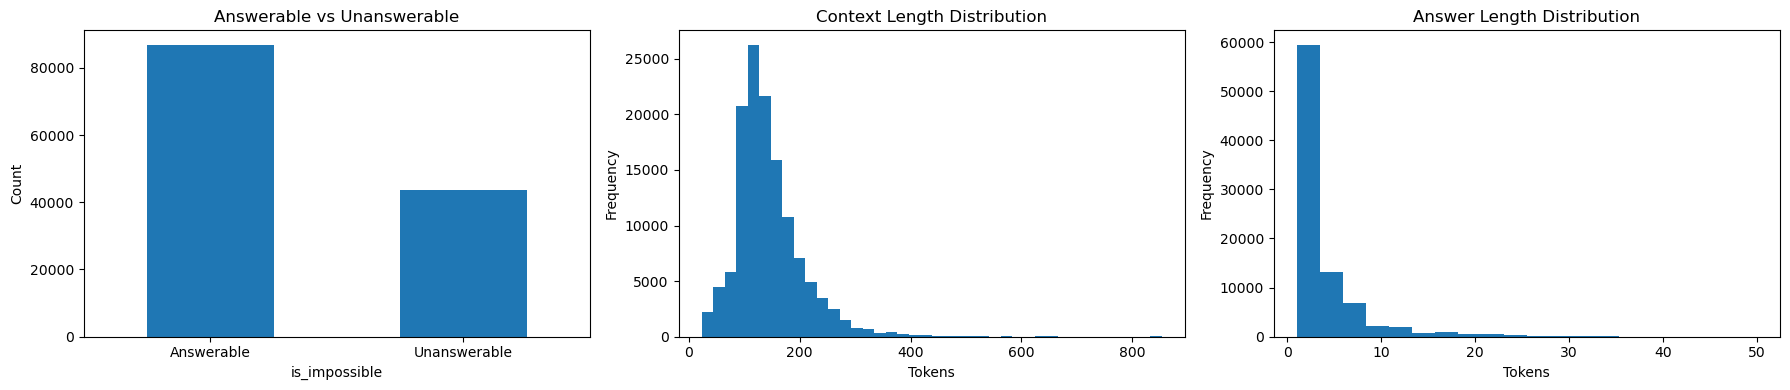

In [5]:

# ============================================================
# 5. EDA
# ============================================================
eda = train_raw_df.copy()
eda["context_tokens"] = eda["context"].apply(lambda x: len(simple_tokenize(x)))
eda["question_tokens"] = eda["question"].apply(lambda x: len(simple_tokenize(x)))
eda["answer_tokens"] = eda["answer_text"].apply(lambda x: len(simple_tokenize(x)) if x else 0)

summary_table = pd.DataFrame({
    "metric": [
        "Total train examples",
        "Answerable train examples",
        "Unanswerable train examples",
        "Mean context length (tokens)",
        "Mean question length (tokens)",
        "Mean answer length (tokens, answerable only)"
    ],
    "value": [
        len(eda),
        int((~eda["is_impossible"]).sum()),
        int(eda["is_impossible"].sum()),
        round(eda["context_tokens"].mean(), 2),
        round(eda["question_tokens"].mean(), 2),
        round(eda.loc[~eda["is_impossible"], "answer_tokens"].mean(), 2)
    ]
})
display(summary_table)
summary_table.to_csv(Path(CONFIG["output_dir"]) / "eda_summary.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
eda["is_impossible"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Answerable vs Unanswerable")
axes[0].set_xticklabels(["Answerable", "Unanswerable"], rotation=0)
axes[0].set_ylabel("Count")
axes[1].hist(eda["context_tokens"], bins=40)
axes[1].set_title("Context Length Distribution")
axes[1].set_xlabel("Tokens")
axes[1].set_ylabel("Frequency")
axes[2].hist(eda.loc[~eda["is_impossible"], "answer_tokens"], bins=20)
axes[2].set_title("Answer Length Distribution")
axes[2].set_xlabel("Tokens")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:

# ============================================================
# 6. Build filtered train/dev sets including answerability labels
# ============================================================
def build_filtered_v2_split(df, max_context_len, max_question_len, max_answer_len):
    rows = []
    for _, row in df.iterrows():
        ctx_tokens = simple_tokenize(row["context"])
        q_tokens = simple_tokenize(row["question"])

        if len(ctx_tokens) > max_context_len:
            continue
        if len(q_tokens) > max_question_len:
            continue

        if row["is_impossible"]:
            rows.append({
                "id": row["id"],
                "title": row["title"],
                "context": row["context"],
                "question": row["question"],
                "answer_text": "",
                "all_answers": row["all_answers"],
                "context_tokens": ctx_tokens,
                "question_tokens": q_tokens,
                "answer_tokens": [],
                "start_idx": 0,
                "end_idx": 0,
                "has_answer": 0
            })
            continue

        start_tok, end_tok, ctx_tokens = char_span_to_token_span(
            row["context"],
            row["answer_text"],
            row["answer_start"]
        )
        if start_tok is None or end_tok is None:
            continue

        ans_tokens = simple_tokenize(row["answer_text"])
        if len(ans_tokens) == 0 or len(ans_tokens) > max_answer_len:
            continue
        if find_sublist_occurrences(ctx_tokens, ans_tokens) != 1:
            continue
        if end_tok >= max_context_len - 1:
            continue

        rows.append({
            "id": row["id"],
            "title": row["title"],
            "context": row["context"],
            "question": row["question"],
            "answer_text": row["answer_text"],
            "all_answers": row["all_answers"],
            "context_tokens": ctx_tokens,
            "question_tokens": q_tokens,
            "answer_tokens": ans_tokens,
            "start_idx": start_tok,
            "end_idx": end_tok,
            "has_answer": 1
        })

    return pd.DataFrame(rows)

train_df = build_filtered_v2_split(
    train_raw_df, CONFIG["max_context_len"], CONFIG["max_question_len"], CONFIG["max_answer_len"]
)
dev_df = build_filtered_v2_split(
    dev_raw_df, CONFIG["max_context_len"], CONFIG["max_question_len"], CONFIG["max_answer_len"]
)

if CONFIG["max_train_examples"] is not None:
    train_df = train_df.iloc[:CONFIG["max_train_examples"]].copy().reset_index(drop=True)
if CONFIG["max_dev_examples"] is not None:
    dev_df = dev_df.iloc[:CONFIG["max_dev_examples"]].copy().reset_index(drop=True)

print("Filtered train examples:", train_df.shape)
print("Filtered dev examples:", dev_df.shape)

split_table = pd.DataFrame({
    "split": ["train_filtered", "dev_filtered", "train_raw", "dev_raw"],
    "n_examples": [len(train_df), len(dev_df), len(train_raw_df), len(dev_raw_df)],
    "answerable_examples": [
        int(train_df["has_answer"].sum()),
        int(dev_df["has_answer"].sum()),
        int((~train_raw_df["is_impossible"]).sum()),
        int((~dev_raw_df["is_impossible"]).sum())
    ],
    "unanswerable_examples": [
        int((1 - train_df["has_answer"]).sum()),
        int((1 - dev_df["has_answer"]).sum()),
        int(train_raw_df["is_impossible"].sum()),
        int(dev_raw_df["is_impossible"].sum())
    ]
})
display(split_table)
split_table.to_csv(Path(CONFIG["output_dir"]) / "data_split_summary.csv", index=False)


Filtered train examples: (81780, 12)
Filtered dev examples: (7288, 12)


,split,n_examples,answerable_examples,unanswerable_examples
0,train_filtered,81780,50777,31003
1,dev_filtered,7288,3257,4031
2,train_raw,130319,86821,43498
3,dev_raw,11873,5928,5945


In [7]:

# ============================================================
# 7. Vocabulary and GloVe embeddings
# ============================================================
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

counter = Counter()
for _, row in train_df.iterrows():
    counter.update(row["context_tokens"])
    counter.update(row["question_tokens"])

most_common = counter.most_common(CONFIG["max_vocab_size"] - 2)
itos = [PAD_TOKEN, UNK_TOKEN] + [tok for tok, _ in most_common]
stoi = {tok: idx for idx, tok in enumerate(itos)}
print("Vocabulary size:", len(itos))
pd.DataFrame({"token": itos, "index": list(range(len(itos)))}).to_csv(Path(CONFIG["output_dir"]) / "vocabulary.csv", index=False)

def download_glove_if_needed(zip_path, txt_path):
    if os.path.exists(txt_path):
        print("GloVe file already present:", txt_path)
        return
    zip_url = "https://nlp.stanford.edu/data/glove.6B.zip"
    if not os.path.exists(zip_path):
        print("Downloading GloVe zip... this happens only once.")
        urllib.request.urlretrieve(zip_url, zip_path)
    print("Extracting GloVe 100d file...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extract("glove.6B.100d.txt", path=os.path.dirname(zip_path))

def load_glove_subset(glove_txt_path, vocab, emb_dim):
    embeddings = {}
    vocab_set = set(vocab)
    with open(glove_txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            if word in vocab_set:
                vector = np.asarray(parts[1:], dtype=np.float32)
                if len(vector) == emb_dim:
                    embeddings[word] = vector
    return embeddings

download_glove_if_needed(CONFIG["glove_zip_path"], CONFIG["glove_txt_path"])
glove_vectors = load_glove_subset(CONFIG["glove_txt_path"], itos, CONFIG["glove_dim"])
print("Matched GloVe vectors:", len(glove_vectors), "out of", len(itos))

embedding_matrix = np.random.normal(loc=0.0, scale=0.05, size=(len(itos), CONFIG["embedding_dim"])).astype(np.float32)
embedding_matrix[stoi[PAD_TOKEN]] = np.zeros(CONFIG["embedding_dim"], dtype=np.float32)
for token, idx in stoi.items():
    if token in glove_vectors:
        embedding_matrix[idx] = glove_vectors[token]

np.save(Path(CONFIG["artifact_dir"]) / "embedding_matrix.npy", embedding_matrix)
print("Embedding matrix shape:", embedding_matrix.shape)


Vocabulary size: 60000
GloVe file already present: embeddings/glove.6B.100d.txt
Matched GloVe vectors: 51782 out of 60000
Embedding matrix shape: (60000, 100)


In [8]:

# ============================================================
# 8. Dataset objects and dataloaders
# ============================================================
def encode_tokens(tokens, stoi, max_len):
    ids = [stoi.get(tok, stoi[UNK_TOKEN]) for tok in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [stoi[PAD_TOKEN]] * (max_len - len(ids))
    return ids

class QADatasetV2(Dataset):
    def __init__(self, dataframe, stoi, max_context_len, max_question_len):
        self.df = dataframe.reset_index(drop=True)
        self.stoi = stoi
        self.max_context_len = max_context_len
        self.max_question_len = max_question_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        context_ids = encode_tokens(row["context_tokens"], self.stoi, self.max_context_len)
        question_ids = encode_tokens(row["question_tokens"], self.stoi, self.max_question_len)

        context_len = min(len(row["context_tokens"]), self.max_context_len)
        question_len = min(len(row["question_tokens"]), self.max_question_len)

        context_mask = [1 if tok != self.stoi[PAD_TOKEN] else 0 for tok in context_ids]
        question_mask = [1 if tok != self.stoi[PAD_TOKEN] else 0 for tok in question_ids]

        return {
            "context_ids": torch.tensor(context_ids, dtype=torch.long),
            "question_ids": torch.tensor(question_ids, dtype=torch.long),
            "context_mask": torch.tensor(context_mask, dtype=torch.float32),
            "question_mask": torch.tensor(question_mask, dtype=torch.float32),
            "context_len": torch.tensor(context_len, dtype=torch.long),
            "question_len": torch.tensor(question_len, dtype=torch.long),
            "start_positions": torch.tensor(int(row["start_idx"]), dtype=torch.long),
            "end_positions": torch.tensor(int(row["end_idx"]), dtype=torch.long),
            "has_answer": torch.tensor(int(row["has_answer"]), dtype=torch.float32),
            "context_tokens": row["context_tokens"],
            "question_text": row["question"],
            "answer_text": row["answer_text"],
            "all_answers": row["all_answers"],
            "id": row["id"],
            "context_text": row["context"],
        }

def qa_collate_fn(batch):
    return {
        "context_ids": torch.stack([x["context_ids"] for x in batch]),
        "question_ids": torch.stack([x["question_ids"] for x in batch]),
        "context_mask": torch.stack([x["context_mask"] for x in batch]),
        "question_mask": torch.stack([x["question_mask"] for x in batch]),
        "context_len": torch.stack([x["context_len"] for x in batch]),
        "question_len": torch.stack([x["question_len"] for x in batch]),
        "start_positions": torch.stack([x["start_positions"] for x in batch]),
        "end_positions": torch.stack([x["end_positions"] for x in batch]),
        "has_answer": torch.stack([x["has_answer"] for x in batch]),
        "context_tokens": [x["context_tokens"] for x in batch],
        "question_text": [x["question_text"] for x in batch],
        "answer_text": [x["answer_text"] for x in batch],
        "all_answers": [x["all_answers"] for x in batch],
        "id": [x["id"] for x in batch],
        "context_text": [x["context_text"] for x in batch],
    }

train_dataset = QADatasetV2(train_df, stoi, CONFIG["max_context_len"], CONFIG["max_question_len"])
dev_dataset = QADatasetV2(dev_df, stoi, CONFIG["max_context_len"], CONFIG["max_question_len"])

pin_memory_flag = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, collate_fn=qa_collate_fn, pin_memory=pin_memory_flag)
dev_loader = DataLoader(dev_dataset, batch_size=CONFIG["batch_size"], shuffle=False, collate_fn=qa_collate_fn, pin_memory=pin_memory_flag)

print("Train batches:", len(train_loader))
print("Dev batches:", len(dev_loader))


Train batches: 1278
Dev batches: 114


In [9]:

# ============================================================
# 9. BiLSTM + Attention QA model with answerability head
# ============================================================
class BetterBiLSTMQAWithNoAnswer(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=96, dropout=0.30, pad_idx=0):
        super().__init__()
        vocab_size, emb_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = True

        self.dropout = nn.Dropout(dropout)
        self.question_encoder = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.context_encoder = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.attn_linear_c = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.attn_linear_q = nn.Linear(hidden_dim * 2, 1, bias=False)

        fused_dim = hidden_dim * 2 * 4
        self.fusion = nn.Linear(fused_dim, hidden_dim * 2)

        self.modeling_lstm = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True, bidirectional=True)

        self.start_classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
        self.end_classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
        self.answerability_classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def _encode(self, emb, lengths, lstm):
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = lstm(packed)
        unpacked_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=emb.size(1))
        return unpacked_out

    def masked_mean_pool(self, x, mask):
        mask = mask.unsqueeze(-1)
        x = x * mask
        denom = mask.sum(dim=1).clamp(min=1e-6)
        return x.sum(dim=1) / denom

    def forward(self, context_ids, question_ids, context_mask, question_mask, context_len, question_len):
        context_emb = self.dropout(self.embedding(context_ids))
        question_emb = self.dropout(self.embedding(question_ids))

        context_out = self._encode(context_emb, context_len, self.context_encoder)
        question_out = self._encode(question_emb, question_len, self.question_encoder)

        c_len = context_out.size(1)
        q_len = question_out.size(1)

        s0 = self.attn_linear_c(context_out).expand(-1, -1, q_len)
        s1 = self.attn_linear_q(question_out).transpose(1, 2).expand(-1, c_len, -1)
        s2 = torch.bmm(context_out, question_out.transpose(1, 2)) / math.sqrt(context_out.size(-1))
        similarity = s0 + s1 + s2

        q_mask_expanded = question_mask.unsqueeze(1).expand_as(similarity)
        similarity = similarity.masked_fill(q_mask_expanded == 0, -1e9)

        c2q_weights = torch.softmax(similarity, dim=2)
        c2q = torch.bmm(c2q_weights, question_out)

        max_similarity_per_context = similarity.max(dim=2).values
        max_similarity_per_context = max_similarity_per_context.masked_fill(context_mask == 0, -1e9)
        q2c_weights = torch.softmax(max_similarity_per_context, dim=1).unsqueeze(1)
        q2c_vector = torch.bmm(q2c_weights, context_out)
        q2c = q2c_vector.expand(-1, c_len, -1)

        fused = torch.cat([context_out, c2q, context_out * c2q, context_out * q2c], dim=-1)
        fused = self.dropout(torch.tanh(self.fusion(fused)))
        modeled_out = self._encode(fused, context_len, self.modeling_lstm)
        modeled_out = self.dropout(modeled_out)

        start_logits = self.start_classifier(modeled_out).squeeze(-1)
        end_logits = self.end_classifier(modeled_out).squeeze(-1)
        start_logits = start_logits.masked_fill(context_mask == 0, -1e9)
        end_logits = end_logits.masked_fill(context_mask == 0, -1e9)

        pooled_context = self.masked_mean_pool(modeled_out, context_mask)
        answerability_logit = self.answerability_classifier(pooled_context).squeeze(-1)

        return start_logits, end_logits, answerability_logit

model = BetterBiLSTMQAWithNoAnswer(
    embedding_matrix=embedding_matrix,
    hidden_dim=CONFIG["hidden_dim"],
    dropout=CONFIG["dropout"],
    pad_idx=stoi[PAD_TOKEN]
).to(device)

print(model)


BetterBiLSTMQAWithNoAnswer(
  (embedding): Embedding(60000, 100, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (question_encoder): LSTM(100, 96, batch_first=True, bidirectional=True)
  (context_encoder): LSTM(100, 96, batch_first=True, bidirectional=True)
  (attn_linear_c): Linear(in_features=192, out_features=1, bias=False)
  (attn_linear_q): Linear(in_features=192, out_features=1, bias=False)
  (fusion): Linear(in_features=768, out_features=192, bias=True)
  (modeling_lstm): LSTM(192, 96, batch_first=True, bidirectional=True)
  (start_classifier): Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=96, out_features=1, bias=True)
  )
  (end_classifier): Sequential(
    (0): Linear(in_features=192, out_features=96, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=96, out_features=1, bias=True)
  )
  (answerability_classifier)

In [10]:

# ============================================================
# 10. Training utilities
# ============================================================
span_criterion = nn.CrossEntropyLoss(reduction="none")
answerability_criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

def decode_best_span(start_logits, end_logits, context_mask=None, max_answer_len=8, return_scores=False):
    start_logits_np = start_logits.detach().cpu().numpy()
    end_logits_np = end_logits.detach().cpu().numpy()
    context_mask_np = context_mask.detach().cpu().numpy() if context_mask is not None else None

    pred_starts, pred_ends, pred_scores = [], [], []
    for i in range(len(start_logits_np)):
        s_log = start_logits_np[i].copy()
        e_log = end_logits_np[i].copy()
        valid_len = int(context_mask_np[i].sum()) if context_mask_np is not None else len(s_log)

        best_score = -1e18
        best_s, best_e = 0, 0
        for s in range(valid_len):
            for e in range(s, min(valid_len, s + max_answer_len)):
                score = s_log[s] + e_log[e] - 0.03 * (e - s)
                if score > best_score:
                    best_score = score
                    best_s, best_e = s, e

        pred_starts.append(best_s)
        pred_ends.append(best_e)
        pred_scores.append(best_score)

    if return_scores:
        return pred_starts, pred_ends, pred_scores
    return pred_starts, pred_ends

def token_level_binary_vectors(start_idx, end_idx, seq_len):
    vec = np.zeros(seq_len, dtype=int)
    vec[start_idx:end_idx + 1] = 1
    return vec

def compute_span_metrics_answerable_only(gold_starts, gold_ends, pred_starts, pred_ends, context_tokens_batch):
    if len(gold_starts) == 0:
        return {
            "start_accuracy": np.nan,
            "end_accuracy": np.nan,
            "exact_match": np.nan,
            "token_accuracy": np.nan,
            "token_precision": np.nan,
            "token_recall": np.nan,
            "token_f1": np.nan,
            "confusion_matrix": np.array([[0, 0], [0, 0]])
        }

    start_acc = accuracy_score(gold_starts, pred_starts)
    end_acc = accuracy_score(gold_ends, pred_ends)
    exact_match_list = [int(gs == ps and ge == pe) for gs, ge, ps, pe in zip(gold_starts, gold_ends, pred_starts, pred_ends)]
    exact_match = float(np.mean(exact_match_list))

    all_gold_binary, all_pred_binary = [], []
    for gs, ge, ps, pe, ctx_tokens in zip(gold_starts, gold_ends, pred_starts, pred_ends, context_tokens_batch):
        seq_len = len(ctx_tokens)
        all_gold_binary.extend(token_level_binary_vectors(gs, ge, seq_len).tolist())
        all_pred_binary.extend(token_level_binary_vectors(ps, pe, seq_len).tolist())

    precision, recall, f1, _ = precision_recall_fscore_support(all_gold_binary, all_pred_binary, average="binary", zero_division=0)
    token_acc = accuracy_score(all_gold_binary, all_pred_binary)
    cm = confusion_matrix(all_gold_binary, all_pred_binary)

    return {
        "start_accuracy": start_acc,
        "end_accuracy": end_acc,
        "exact_match": exact_match,
        "token_accuracy": token_acc,
        "token_precision": precision,
        "token_recall": recall,
        "token_f1": f1,
        "confusion_matrix": cm
    }

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    epoch_loss = 0.0
    all_gold_starts, all_gold_ends, all_pred_starts, all_pred_ends, all_context_tokens = [], [], [], [], []
    all_has_answer_gold, all_has_answer_pred = [], []

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            context_ids = batch["context_ids"].to(device)
            question_ids = batch["question_ids"].to(device)
            context_mask = batch["context_mask"].to(device)
            question_mask = batch["question_mask"].to(device)
            context_len = batch["context_len"].to(device)
            question_len = batch["question_len"].to(device)
            start_positions = batch["start_positions"].to(device)
            end_positions = batch["end_positions"].to(device)
            has_answer = batch["has_answer"].to(device)

            start_logits, end_logits, answerability_logit = model(
                context_ids=context_ids,
                question_ids=question_ids,
                context_mask=context_mask,
                question_mask=question_mask,
                context_len=context_len,
                question_len=question_len
            )

            start_loss_all = span_criterion(start_logits, start_positions)
            end_loss_all = span_criterion(end_logits, end_positions)
            span_mask = has_answer.float()

            if span_mask.sum() > 0:
                span_loss = 0.5 * (
                    (start_loss_all * span_mask).sum() / span_mask.sum() +
                    (end_loss_all * span_mask).sum() / span_mask.sum()
                )
            else:
                span_loss = torch.tensor(0.0, device=device)

            answerability_loss = answerability_criterion(answerability_logit, has_answer)
            loss = CONFIG["span_loss_weight"] * span_loss + CONFIG["answerability_loss_weight"] * answerability_loss

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            epoch_loss += loss.item() * context_ids.size(0)

            pred_starts, pred_ends = decode_best_span(start_logits, end_logits, context_mask=context_mask, max_answer_len=CONFIG["max_answer_len"])
            pred_has_answer = (torch.sigmoid(answerability_logit) >= 0.5).long().detach().cpu().tolist()
            gold_has_answer = has_answer.long().detach().cpu().tolist()

            all_has_answer_gold.extend(gold_has_answer)
            all_has_answer_pred.extend(pred_has_answer)

            for i, gold_flag in enumerate(gold_has_answer):
                if gold_flag == 1:
                    all_gold_starts.append(int(start_positions[i].detach().cpu().item()))
                    all_gold_ends.append(int(end_positions[i].detach().cpu().item()))
                    all_pred_starts.append(pred_starts[i])
                    all_pred_ends.append(pred_ends[i])
                    all_context_tokens.append(batch["context_tokens"][i])

    avg_loss = epoch_loss / len(loader.dataset)
    span_metrics = compute_span_metrics_answerable_only(all_gold_starts, all_gold_ends, all_pred_starts, all_pred_ends, all_context_tokens)
    answerability_acc = accuracy_score(all_has_answer_gold, all_has_answer_pred)

    metrics = dict(span_metrics)
    metrics["loss"] = avg_loss
    metrics["answerability_accuracy"] = answerability_acc
    return metrics


In [11]:

# ============================================================
# 11. Train model
# ============================================================
history = []
best_val_score = -1.0
best_state_dict = None
epochs_without_improvement = 0
train_start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start_time = time.time()

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, dev_loader, optimizer=None)

    elapsed = time.time() - epoch_start_time
    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_exact_match": train_metrics["exact_match"],
        "val_exact_match": val_metrics["exact_match"],
        "train_token_f1": train_metrics["token_f1"],
        "val_token_f1": val_metrics["token_f1"],
        "train_start_acc": train_metrics["start_accuracy"],
        "val_start_acc": val_metrics["start_accuracy"],
        "train_end_acc": train_metrics["end_accuracy"],
        "val_end_acc": val_metrics["end_accuracy"],
        "train_answerability_acc": train_metrics["answerability_accuracy"],
        "val_answerability_acc": val_metrics["answerability_accuracy"],
        "epoch_seconds": elapsed,
        "learning_rate": optimizer.param_groups[0]["lr"]
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"train_f1={train_metrics['token_f1']:.4f} | "
        f"val_f1={val_metrics['token_f1']:.4f} | "
        f"val_em={val_metrics['exact_match']:.4f} | "
        f"val_ans_acc={val_metrics['answerability_accuracy']:.4f} | "
        f"time={elapsed:.1f}s"
    )

    current_score = (
        0.50 * (0.0 if pd.isna(val_metrics["token_f1"]) else val_metrics["token_f1"]) +
        0.30 * (0.0 if pd.isna(val_metrics["exact_match"]) else val_metrics["exact_match"]) +
        0.20 * val_metrics["answerability_accuracy"]
    )
    scheduler.step(current_score)

    if current_score > best_val_score:
        best_val_score = current_score
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CONFIG["patience"]:
            print("Early stopping triggered.")
            break

total_train_time = time.time() - train_start_time
print(f"Total training time: {total_train_time:.2f} seconds")

history_df = pd.DataFrame(history)
display(history_df.head())
history_df.to_csv(Path(CONFIG["output_dir"]) / "training_history.csv", index=False)

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

torch.save(model.state_dict(), Path(CONFIG["artifact_dir"]) / "full_train_best_model_with_noanswer.pt")


Epoch 01 | train_loss=3.6636 | val_loss=3.3232 | train_f1=0.1672 | val_f1=0.2330 | val_em=0.1805 | val_ans_acc=0.4528 | time=1306.6s
Epoch 02 | train_loss=2.9826 | val_loss=2.9777 | train_f1=0.2842 | val_f1=0.3053 | val_em=0.2312 | val_ans_acc=0.5479 | time=1395.5s
Epoch 03 | train_loss=2.6298 | val_loss=2.7589 | train_f1=0.3657 | val_f1=0.3565 | val_em=0.2683 | val_ans_acc=0.5543 | time=1368.1s
Epoch 04 | train_loss=2.3485 | val_loss=2.6602 | train_f1=0.4343 | val_f1=0.3875 | val_em=0.2935 | val_ans_acc=0.5547 | time=1367.6s
Epoch 05 | train_loss=2.1351 | val_loss=2.5808 | train_f1=0.4876 | val_f1=0.4267 | val_em=0.3150 | val_ans_acc=0.5703 | time=2065.4s
Epoch 06 | train_loss=1.9477 | val_loss=2.4755 | train_f1=0.5355 | val_f1=0.4429 | val_em=0.3337 | val_ans_acc=0.5733 | time=1356.3s
Epoch 07 | train_loss=1.7861 | val_loss=2.4507 | train_f1=0.5750 | val_f1=0.4674 | val_em=0.3383 | val_ans_acc=0.5609 | time=1362.7s
Epoch 08 | train_loss=1.6549 | val_loss=2.4598 | train_f1=0.6061 | va

,epoch,train_loss,val_loss,train_exact_match,val_exact_match,train_token_f1,val_token_f1,train_start_acc,val_start_acc,train_end_acc,val_end_acc,train_answerability_acc,val_answerability_acc,epoch_seconds,learning_rate
0,1,3.663556,3.323239,0.125017,0.180534,0.167223,0.233020,0.158694,0.223519,0.177187,0.246546,0.622866,0.452799,1306.595961,0.0007
1,2,2.982598,2.977655,0.221537,0.231194,0.284162,0.305291,0.268232,0.290144,0.299289,0.306110,0.637271,0.547887,1395.545259,0.0007
2,3,2.629826,2.758922,0.282628,0.268345,0.365665,0.356518,0.340489,0.331901,0.376982,0.356770,0.652653,0.554336,1368.052220,0.0007
3,4,2.348543,2.660173,0.336865,0.293522,0.434265,0.387494,0.404711,0.358305,0.443449,0.390543,0.669504,0.554748,1367.628605,0.0007
4,5,2.135084,2.580831,0.379325,0.315014,0.487623,0.426690,0.452843,0.386552,0.494358,0.419097,0.679249,0.570252,2065.413555,0.0007


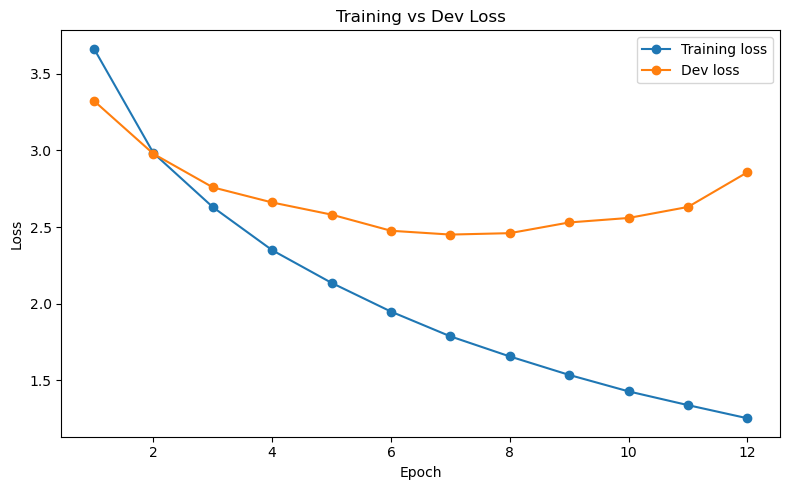

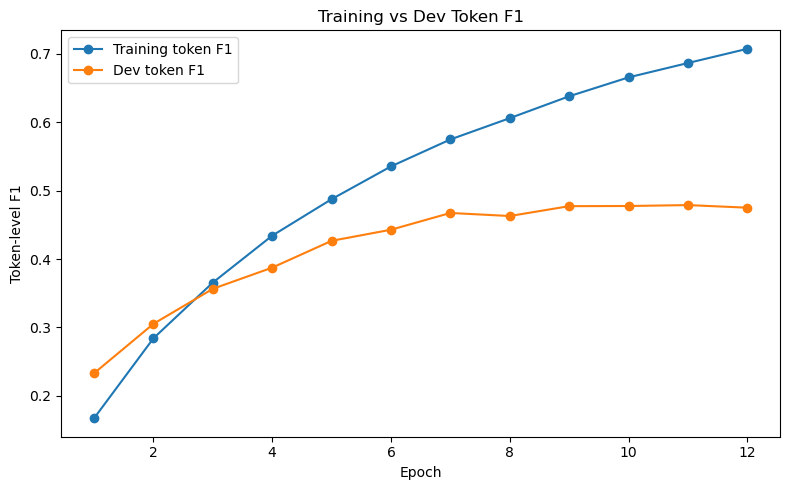

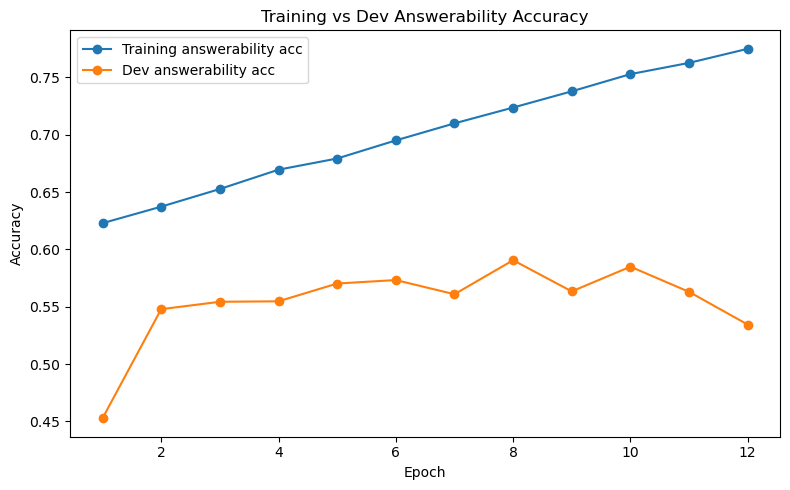

In [12]:

# ============================================================
# 12. Plot curves
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Dev loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training vs Dev Loss")
plt.legend(); plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_token_f1"], marker="o", label="Training token F1")
plt.plot(history_df["epoch"], history_df["val_token_f1"], marker="o", label="Dev token F1")
plt.xlabel("Epoch"); plt.ylabel("Token-level F1"); plt.title("Training vs Dev Token F1")
plt.legend(); plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "f1_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_answerability_acc"], marker="o", label="Training answerability acc")
plt.plot(history_df["epoch"], history_df["val_answerability_acc"], marker="o", label="Dev answerability acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training vs Dev Answerability Accuracy")
plt.legend(); plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "answerability_curve.png", dpi=150, bbox_inches="tight")
plt.show()


,metric,value
0,Start accuracy (answerable only),0.435063
1,End accuracy (answerable only),0.463924
2,Exact span match (answerable only),0.355542
3,Token accuracy (answerable only),0.974059
4,Token precision (answerable only),0.494674
5,Token recall (answerable only),0.461702
6,Token F1 (answerable only),0.477620
7,Answerability accuracy (all filtered dev),0.584934
8,Total training time (seconds),16989.531672


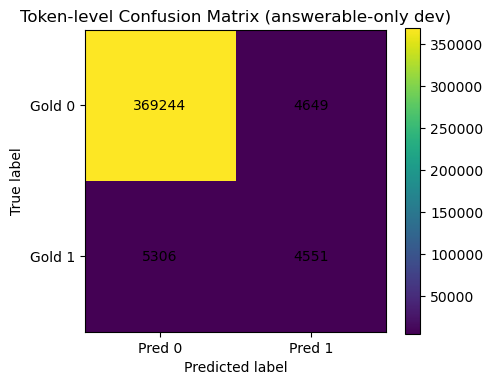

In [13]:

# ============================================================
# 13. Internal dev evaluation
# ============================================================
dev_metrics = run_epoch(model, dev_loader, optimizer=None)
final_metrics_table = pd.DataFrame({
    "metric": [
        "Start accuracy (answerable only)",
        "End accuracy (answerable only)",
        "Exact span match (answerable only)",
        "Token accuracy (answerable only)",
        "Token precision (answerable only)",
        "Token recall (answerable only)",
        "Token F1 (answerable only)",
        "Answerability accuracy (all filtered dev)",
        "Total training time (seconds)"
    ],
    "value": [
        dev_metrics["start_accuracy"],
        dev_metrics["end_accuracy"],
        dev_metrics["exact_match"],
        dev_metrics["token_accuracy"],
        dev_metrics["token_precision"],
        dev_metrics["token_recall"],
        dev_metrics["token_f1"],
        dev_metrics["answerability_accuracy"],
        total_train_time
    ]
})
display(final_metrics_table)
final_metrics_table.to_csv(Path(CONFIG["output_dir"]) / "dev_filtered_metrics.csv", index=False)

cm = dev_metrics["confusion_matrix"]
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Token-level Confusion Matrix (answerable-only dev)")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Gold 0", "Gold 1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(Path(CONFIG["output_dir"]) / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:

# ============================================================
# 14. Sample predictions
# ============================================================
def predict_batch(model, batch):
    model.eval()
    with torch.no_grad():
        context_ids = batch["context_ids"].to(device)
        question_ids = batch["question_ids"].to(device)
        context_mask = batch["context_mask"].to(device)
        question_mask = batch["question_mask"].to(device)
        context_len = batch["context_len"].to(device)
        question_len = batch["question_len"].to(device)

        start_logits, end_logits, answerability_logit = model(
            context_ids=context_ids,
            question_ids=question_ids,
            context_mask=context_mask,
            question_mask=question_mask,
            context_len=context_len,
            question_len=question_len
        )

        pred_starts, pred_ends = decode_best_span(start_logits, end_logits, context_mask=context_mask, max_answer_len=CONFIG["max_answer_len"])
        pred_has_answer = (torch.sigmoid(answerability_logit) >= 0.5).long().detach().cpu().tolist()
        pred_na_prob = (1.0 - torch.sigmoid(answerability_logit)).detach().cpu().tolist()

    predictions = []
    for i in range(len(pred_starts)):
        ctx_tokens = batch["context_tokens"][i]
        pred_answer = span_tokens_to_text(ctx_tokens, pred_starts[i], pred_ends[i]) if pred_has_answer[i] == 1 else ""
        predictions.append({
            "id": batch["id"][i],
            "question": batch["question_text"][i],
            "gold_answer": batch["answer_text"][i],
            "gold_has_answer": 1 if batch["answer_text"][i] != "" else 0,
            "pred_answer": pred_answer,
            "pred_has_answer": pred_has_answer[i],
            "pred_no_answer_prob": pred_na_prob[i],
            "pred_start": pred_starts[i],
            "pred_end": pred_ends[i],
            "exact_match": exact_match_normalized(batch["answer_text"][i], pred_answer),
            "f1": simple_f1(batch["answer_text"][i], pred_answer)
        })
    return predictions

sample_predictions = []
for batch in dev_loader:
    sample_predictions.extend(predict_batch(model, batch))
    if len(sample_predictions) >= 40:
        break

sample_predictions_df = pd.DataFrame(sample_predictions[:40])
display(sample_predictions_df.head(10))
sample_predictions_df.to_csv(Path(CONFIG["output_dir"]) / "sample_predictions.csv", index=False)


,id,question,gold_answer,gold_has_answer,pred_answer,pred_has_answer,pred_no_answer_prob,pred_start,pred_end,exact_match,f1
0,56ddde6b9a695914005b9628,In what country is Normandy located?,France,1,france,1,0.156703,34,34,1,1.000000
1,56ddde6b9a695914005b9629,When were the Normans in Normandy?,10th and 11th centuries,1,first half of the 10th century,1,0.173974,123,128,0,0.222222
2,56ddde6b9a695914005b962a,From which countries did the Norse originate?,"Denmark, Iceland and Norway",1,"denmark, iceland and norway",1,0.052538,55,59,1,1.000000
3,56ddde6b9a695914005b962b,Who was the Norse leader?,Rollo,1,rollo,1,0.168630,65,65,1,1.000000
4,56ddde6b9a695914005b962c,What century did the Normans first gain their ...,10th century,1,10th,1,0.172563,127,127,0,0.666667
5,5ad39d53604f3c001a3fe8d1,Who gave their name to Normandy in the 1000's ...,,0,,0,0.555233,64,65,1,1.000000
6,5ad39d53604f3c001a3fe8d2,What is France a region of?,,0,france,1,0.302379,34,34,0,0.000000
7,5ad39d53604f3c001a3fe8d3,Who did King Charles III swear fealty to?,,0,king charles iii of west francia,1,0.057126,72,77,0,0.000000
8,5ad39d53604f3c001a3fe8d4,When did the Frankish identity emerge?,,0,first half of the 10th century,1,0.053488,123,128,0,0.000000
9,56dde0379a695914005b9636,What is the original meaning of the word Norman?,Viking,1,normant,1,0.070330,17,17,0,0.000000


In [15]:

# ============================================================
# 15. Full dev prediction helper for official SQuAD v2 eval
# ============================================================
def predict_on_window(context_tokens, question, model, stoi, max_context_len, max_question_len):
    question_tokens = simple_tokenize(question)[:max_question_len]

    context_ids = torch.tensor([encode_tokens(context_tokens, stoi, max_context_len)], dtype=torch.long, device=device)
    question_ids = torch.tensor([encode_tokens(question_tokens, stoi, max_question_len)], dtype=torch.long, device=device)

    context_mask = (context_ids != stoi[PAD_TOKEN]).float()
    question_mask = (question_ids != stoi[PAD_TOKEN]).float()
    context_len = context_mask.sum(dim=1).long()
    question_len = question_mask.sum(dim=1).long()

    model.eval()
    with torch.no_grad():
        start_logits, end_logits, answerability_logit = model(
            context_ids=context_ids,
            question_ids=question_ids,
            context_mask=context_mask,
            question_mask=question_mask,
            context_len=context_len,
            question_len=question_len
        )
        pred_start, pred_end, pred_score = decode_best_span(
            start_logits, end_logits, context_mask=context_mask,
            max_answer_len=CONFIG["max_answer_len"], return_scores=True
        )
        no_answer_prob = float(1.0 - torch.sigmoid(answerability_logit).detach().cpu().item())

    pred_text = span_tokens_to_text(context_tokens, pred_start[0], pred_end[0])
    return pred_text, float(pred_score[0]), no_answer_prob

def answer_question_long_context(context, question, model, stoi, max_context_len, max_question_len, stride):
    context_tokens = simple_tokenize(context)

    if len(context_tokens) <= max_context_len:
        return predict_on_window(context_tokens, question, model, stoi, max_context_len, max_question_len)

    best_answer = ""
    best_score = -1e18
    best_no_answer_prob = 1.0

    for start in range(0, len(context_tokens), stride):
        window_tokens = context_tokens[start:start + max_context_len]
        if not window_tokens:
            continue

        pred_text, pred_score, no_answer_prob = predict_on_window(
            window_tokens, question, model, stoi, max_context_len, max_question_len
        )

        if pred_score > best_score and pred_text != "":
            best_score = pred_score
            best_answer = pred_text
            best_no_answer_prob = no_answer_prob

        if start + max_context_len >= len(context_tokens):
            break

    if best_answer == "":
        best_no_answer_prob = max(best_no_answer_prob, 0.5)

    return best_answer, best_score, best_no_answer_prob


In [16]:

# ============================================================
# 16. Generate predictions for ALL dev questions
# ============================================================
dev_pred_dict = {}
dev_na_prob_dict = {}

all_rows = dev_raw_df.to_dict("records")
prediction_start_time = time.time()

for idx, row in enumerate(all_rows, start=1):
    pred_answer, pred_score, no_answer_prob = answer_question_long_context(
        context=row["context"],
        question=row["question"],
        model=model,
        stoi=stoi,
        max_context_len=CONFIG["max_context_len"],
        max_question_len=CONFIG["max_question_len"],
        stride=CONFIG["context_stride"]
    )

    final_answer = "" if no_answer_prob >= 0.5 else pred_answer
    dev_pred_dict[row["id"]] = final_answer
    dev_na_prob_dict[row["id"]] = float(no_answer_prob)

    if idx % 2000 == 0:
        print(f"Processed {idx}/{len(all_rows)} dev questions")

prediction_elapsed = time.time() - prediction_start_time
print(f"Finished all dev predictions in {prediction_elapsed:.2f} seconds")

pred_path = Path(CONFIG["validation_output_dir"]) / "dev_predictions.json"
na_prob_path = Path(CONFIG["validation_output_dir"]) / "dev_na_probs.json"

with open(pred_path, "w", encoding="utf-8") as f:
    json.dump(dev_pred_dict, f, ensure_ascii=False, indent=2)
with open(na_prob_path, "w", encoding="utf-8") as f:
    json.dump(dev_na_prob_dict, f, ensure_ascii=False, indent=2)

print("Saved:", pred_path)
print("Saved:", na_prob_path)


Processed 2000/11873 dev questions
Processed 4000/11873 dev questions
Processed 6000/11873 dev questions
Processed 8000/11873 dev questions
Processed 10000/11873 dev questions
Finished all dev predictions in 685.73 seconds
Saved: dev_validation_outputs_with_noanswer\dev_predictions.json
Saved: dev_validation_outputs_with_noanswer\dev_na_probs.json


In [24]:
# ============================================================
# 17. Generate predictions for ALL dev questions
# ============================================================
from pathlib import Path
import json
import torch

# Make sure output folder exists
output_dir = Path(CONFIG["validation_output_dir"])
output_dir.mkdir(exist_ok=True)

pred_path = output_dir / "dev_predictions.json"
na_prob_path = output_dir / "dev_na_probs.json"

def predict_single_example_with_noanswer(context, question, model, stoi, max_context_len, max_question_len, max_answer_len):
    """
    Run the custom QA model on one (context, question) pair and return:
    - predicted answer text
    - no-answer probability
    """

    # Tokenise and truncate
    context_tokens = simple_tokenize(context)[:max_context_len]
    question_tokens = simple_tokenize(question)[:max_question_len]

    # Encode tokens as integer ids
    context_ids = torch.tensor(
        [encode_tokens(context_tokens, stoi, max_context_len)],
        dtype=torch.long,
        device=device
    )
    question_ids = torch.tensor(
        [encode_tokens(question_tokens, stoi, max_question_len)],
        dtype=torch.long,
        device=device
    )

    # Build masks and lengths
    context_mask = (context_ids != stoi[PAD_TOKEN]).float()
    question_mask = (question_ids != stoi[PAD_TOKEN]).float()
    context_len = context_mask.sum(dim=1).long()
    question_len = question_mask.sum(dim=1).long()

    # Inference
    model.eval()
    with torch.no_grad():
        start_logits, end_logits, no_answer_logit = model(
            context_ids=context_ids,
            question_ids=question_ids,
            context_mask=context_mask,
            question_mask=question_mask,
            context_len=context_len,
            question_len=question_len
        )

        pred_start, pred_end = decode_best_span(
            start_logits,
            end_logits,
            context_mask=context_mask,
            max_answer_len=max_answer_len
        )

        # Convert model output to probability of "no answer"
        no_answer_prob = torch.sigmoid(no_answer_logit).item()

    pred_text = span_tokens_to_text(context_tokens, pred_start[0], pred_end[0])

    # If model believes question is unanswerable, return empty string
    if no_answer_prob > 0.5:
        pred_text = ""

    return pred_text, float(no_answer_prob)

# ------------------------------------------------------------
# Run prediction on every dev example
# ------------------------------------------------------------
dev_pred_dict = {}
dev_na_prob_dict = {}

model.eval()

for idx, row in dev_df.iterrows():
    pred_text, na_prob = predict_single_example_with_noanswer(
        context=row["context"],
        question=row["question"],
        model=model,
        stoi=stoi,
        max_context_len=CONFIG["max_context_len"],
        max_question_len=CONFIG["max_question_len"],
        max_answer_len=CONFIG["max_answer_len"]
    )

    dev_pred_dict[row["id"]] = pred_text
    dev_na_prob_dict[row["id"]] = na_prob

    if (idx + 1) % 2000 == 0:
        print(f"Processed {idx + 1} / {len(dev_df)} dev examples")

# ------------------------------------------------------------
# Save predictions as ASCII-safe JSON for Windows compatibility
# ------------------------------------------------------------
with open(pred_path, "w", encoding="utf-8") as f:
    json.dump(dev_pred_dict, f, ensure_ascii=True, indent=2)

with open(na_prob_path, "w", encoding="utf-8") as f:
    json.dump(dev_na_prob_dict, f, ensure_ascii=True, indent=2)

print("Saved predictions to:", pred_path)
print("Saved no-answer probabilities to:", na_prob_path)
print("Total predictions:", len(dev_pred_dict))

Processed 2000 / 7288 dev examples
Processed 4000 / 7288 dev examples
Processed 6000 / 7288 dev examples
Saved predictions to: dev_validation_outputs_with_noanswer\dev_predictions.json
Saved no-answer probabilities to: dev_validation_outputs_with_noanswer\dev_na_probs.json
Total predictions: 7288


In [25]:
# ============================================================
# 18. Run official SQuAD v2.0 evaluation
# ============================================================
from pathlib import Path
import json
import pandas as pd

EVAL_SCRIPT = "evaluate-v2.0.py"

DEV_FILE = CONFIG["dev_path"]
pred_path = str(Path(CONFIG["validation_output_dir"]) / "dev_predictions.json")
na_prob_path = str(Path(CONFIG["validation_output_dir"]) / "dev_na_probs.json")
eval_output_path = str(Path(CONFIG["validation_output_dir"]) / "official_dev_eval.json")

for fp in [EVAL_SCRIPT, DEV_FILE, pred_path, na_prob_path]:
    if not Path(fp).exists():
        raise FileNotFoundError(f"Required file not found: {fp}")

print("Running official evaluation...")

!python "{EVAL_SCRIPT}" "{DEV_FILE}" "{pred_path}" --na-prob-file "{na_prob_path}" -o "{eval_output_path}"

if not Path(eval_output_path).exists():
    raise FileNotFoundError(f"Evaluation output file was not created: {eval_output_path}")

with open(eval_output_path, "r", encoding="utf-8") as f:
    official_eval_results = json.load(f)

official_eval_df = pd.DataFrame({
    "metric": list(official_eval_results.keys()),
    "value": list(official_eval_results.values())
})

display(official_eval_df)

official_eval_df.to_csv(
    Path(CONFIG["validation_output_dir"]) / "official_dev_eval.csv",
    index=False
)

Running official evaluation...
Missing prediction for 56dddf4066d3e219004dad5f
Missing prediction for 56dddf4066d3e219004dad60
Missing prediction for 56dddf4066d3e219004dad61
Missing prediction for 5ad3a266604f3c001a3fea27
Missing prediction for 5ad3a266604f3c001a3fea28
Missing prediction for 5ad3a266604f3c001a3fea29
Missing prediction for 5ad3a266604f3c001a3fea2a
Missing prediction for 5ad3a266604f3c001a3fea2b
Missing prediction for 56dde0ba66d3e219004dad75
Missing prediction for 56dde0ba66d3e219004dad76
Missing prediction for 56dde0ba66d3e219004dad77
Missing prediction for 5ad3ad61604f3c001a3fec0d
Missing prediction for 5ad3ad61604f3c001a3fec0e
Missing prediction for 5ad3ad61604f3c001a3fec0f
Missing prediction for 5ad3ad61604f3c001a3fec10
Missing prediction for 56dde1d966d3e219004dad8d
Missing prediction for 56de10b44396321400ee2594
Missing prediction for 56de148dcffd8e1900b4b5bc
Missing prediction for 56de148dcffd8e1900b4b5bd
Missing prediction for 56de148dcffd8e1900b4b5be
Missing p

Traceback (most recent call last):
  File "C:\Users\anwar\evaluate-v2.0.py", line 269, in <module>
    main()
    ~~~~^^
  File "C:\Users\anwar\evaluate-v2.0.py", line 245, in main
    has_ans_eval = make_eval_dict(exact_thresh, f1_thresh, qid_list=has_ans_qids)
  File "C:\Users\anwar\evaluate-v2.0.py", line 116, in make_eval_dict
    ('exact', 100.0 * sum(exact_scores[k] for k in qid_list) / total),
                      ~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\anwar\evaluate-v2.0.py", line 116, in <genexpr>
    ('exact', 100.0 * sum(exact_scores[k] for k in qid_list) / total),
                          ~~~~~~~~~~~~^^^
KeyError: '56dddf4066d3e219004dad5f'


FileNotFoundError: Evaluation output file was not created: dev_validation_outputs_with_noanswer\official_dev_eval.json

Missing prediction for 5ad4d8d65b96ef001a10a365
Missing prediction for 5ad4d8d65b96ef001a10a366
Missing prediction for 57336755d058e614000b5a3c
Missing prediction for 57336755d058e614000b5a3d
Missing prediction for 57336755d058e614000b5a3e
Missing prediction for 57336755d058e614000b5a3f
Missing prediction for 57336755d058e614000b5a40
Missing prediction for 5ad4db9f5b96ef001a10a43e
Missing prediction for 5ad4db9f5b96ef001a10a43f
Missing prediction for 5ad4db9f5b96ef001a10a440
Missing prediction for 5ad4db9f5b96ef001a10a441
Missing prediction for 5ad4db9f5b96ef001a10a442
Missing prediction for 573368044776f41900660a29
Missing prediction for 573368044776f41900660a2a
Missing prediction for 573368044776f41900660a2b
Missing prediction for 573368044776f41900660a2c
Missing prediction for 573368044776f41900660a2d
Missing prediction for 5ad4dc755b96ef001a10a46e
Missing prediction for 5ad4dc755b96ef001a10a46f
Missing prediction for 5ad4dc755b96ef001a10a470
Missing prediction for 5ad4dc755b96ef001

In [26]:

# ============================================================
# 19. Save reproducibility artifacts
# ============================================================
hyperparams_df = pd.DataFrame([{"parameter": k, "value": v} for k, v in CONFIG.items()])
hyperparams_df.to_csv(Path(CONFIG["output_dir"]) / "hyperparameters.csv", index=False)

env_df = pd.DataFrame({
    "library": ["python", "numpy", "pandas", "torch", "matplotlib", "sklearn"],
    "version": [
        ".".join(map(str, list(sys.version_info[:3]))),
        np.__version__,
        pd.__version__,
        torch.__version__,
        plt.matplotlib.__version__,
        __import__("sklearn").__version__
    ]
})
env_df.to_csv(Path(CONFIG["output_dir"]) / "software_versions.csv", index=False)

print("Saved files in outputs_full_train_dev_with_noanswer:")
for p in sorted(Path(CONFIG["output_dir"]).glob("*")):
    print("-", p.name)

print("\nSaved files in dev_validation_outputs_with_noanswer:")
for p in sorted(Path(CONFIG["validation_output_dir"]).glob("*")):
    print("-", p.name)


Saved files in outputs_full_train_dev_with_noanswer:
- answerability_curve.png
- confusion_matrix.png
- data_split_summary.csv
- dev_filtered_metrics.csv
- eda_plots.png
- eda_summary.csv
- f1_curve.png
- hyperparameters.csv
- loss_curve.png
- sample_predictions.csv
- software_versions.csv
- training_history.csv
- vocabulary.csv

Saved files in dev_validation_outputs_with_noanswer:
- dev_na_probs.json
- dev_predictions.json
- evaluate_v2_official.py
- official_eval_images
